# ML Interview Q&A — A 119-Row Corpus, and Why It Has No Model Score
> **119 questions · 7 columns · `ml_interview_questions.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/ml-interview-qa)

This is a hand-written study corpus, not a benchmark. The template this notebook grew
from proposed a supervised task — classify each question into one of 10 categories — and
this version **does not report a headline accuracy for it**, because at 119 rows and 10
classes the fold-to-fold spread is larger than the gap between any two models you would
want to compare. Section 8 measures that instability instead of hiding behind an average.

## TL;DR

- **No model score is reported, and that is the finding.** A TF-IDF classifier on
  `topic_tags` scores between **54.2%** and **87.5%** across five folds of the same
  split — a 33-point swing. Each test fold holds **23-24 rows** across **10** classes,
  so moving one row changes accuracy by about **4.2 points**.
- **`topic_tags` is annotation leakage, not a feature.** The tags were hand-written by
  the same author, at the same time, as the `category` label. **118 of 181** tags appear
  exactly once in the entire corpus, so they are per-question annotations rather than a
  feature space a model could generalise over.
- **Question text alone reaches 34.5%** against a majority-class floor of **18.5%** — a
  real but small effect, on a **444-word** vocabulary. Adding the answer text roughly
  doubles it to **53.7%**, which mostly reflects answers being 7× longer than questions.
- **`answer_length` carries almost nothing about difficulty.** Easy answers median
  **61** words, hard **69**, medium **62** — the three distributions overlap almost
  entirely across a **46-85** word range.
- **The corpus is balanced by design on `difficulty`** but heavily unbalanced on
  `category`: `ML Theory` has **22** questions and `A/B Testing` has **6**.
- **Retrieval is the task it can be scored on.** Ranking all 119 answers for each
  question, plain TF-IDF reaches **Recall@1 = 73.1%** and **Recall@5 = 87.4%**
  against chance rates of 0.8% and 4.2%. Every row is a query, so the effective sample is
  119 rather than the 24 a classification fold gave us.
- **What it is genuinely good for**: study material, retrieval and RAG evaluation, and
  prompt testing — none of which need 119 rows to be a statistical sample.

## Contents

1. [Setup & data loading](#setup)
2. [Objective, and why it changed](#objective)
3. [Data overview](#overview)
4. [Missing data](#missing)
5. [Coverage: categories and difficulty](#coverage)
6. [The text itself](#text)
7. [`topic_tags` is a label, not a feature](#tags)
8. [Why there is no model score](#nomodel)
9. [The better-posed task: retrieval](#retrieval)
10. [What this corpus is actually for](#uses)
11. [Evaluation readiness](#evaluation)
12. [Key findings & takeaways](#findings)

## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 11

MOUNT_GUESS = "/kaggle/input/ml-interview-qa"
MARKER = "ml_interview_questions.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and falling back
    # to "." landed in the kernel working directory, which holds no CSVs at all,
    # so the notebook died on a confusing FileNotFoundError several cells later.
    # The files mount NESTED (the run that taught us this found only
    # /kaggle/input/datasets). Walk the mount tree for the file we actually
    # need, and if it is absent report what *was* mounted, so the next failure
    # is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
print(f"Reading from: {DATA_DIR}")

Reading from: .


In [2]:
df = pd.read_csv(f"{DATA_DIR}/ml_interview_questions.csv")

df["question_words"] = df["question"].str.split().str.len()
df["answer_words"] = df["answer"].str.split().str.len()
df["n_tags"] = df["topic_tags"].str.count(r"\|") + 1

print(f"Shape: {df.shape[0]:,} rows x 7 columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e3:.0f} KB")
print(f"Categories: {df['category'].nunique()}   Difficulty levels: {df['difficulty'].nunique()}")
print(f"Total words of answer text: {df['answer_words'].sum():,}")
print()
print("For scale, 119 rows is smaller than a single mini-batch. Every conclusion below")
print("is reported with that in mind.")
df.head()

Shape: 119 rows x 7 columns
Memory: 80 KB
Categories: 10   Difficulty levels: 3
Total words of answer text: 7,612

For scale, 119 rows is smaller than a single mini-batch. Every conclusion below
is reported with that in mind.


,id,question,answer,category,difficulty,topic_tags,answer_length,question_words,answer_words,n_tags
0,03ab89d94d,Explain diffusion models and how they generate...,Diffusion models define a forward process that...,Deep Learning,hard,generative models|diffusion|image generation,66,8,66,3
1,520c63abb2,"What is the difference between INNER JOIN, LEF...",INNER JOIN returns rows with matching keys in ...,SQL,easy,joins|SQL basics,70,14,70,2
2,d8282bb3be,"What is the difference between mean, median, a...","Mean is the arithmetic average (sum / count), ...",Statistics,easy,descriptive statistics|central tendency,54,9,54,2
3,632d9b0409,What is batch normalization?,Batch normalization normalizes the input of ea...,Deep Learning,easy,normalization|neural networks|training,61,4,61,3
4,b57ffb7365,"Explain precision, recall, and F1-score.",Precision = TP/(TP+FP): of all positive predic...,ML Theory,easy,classification metrics|evaluation,64,5,64,2


## 2. Objective, and Why It Changed <a id='objective'></a>

**The template's objective** was: classify `question` text into one of the 10 `category`
values, scored by accuracy and macro-F1 under stratified 5-fold CV.

**The objective of this notebook** is to establish whether that task can be *evaluated*
before reporting a number for it — and, having found that it cannot, to characterise the
corpus for the uses it does support.

**Why the change.** With 119 rows and 10 classes, a stratified 5-fold test set holds
roughly 24 rows. Spread across 10 categories, that is 2-3 examples per class per fold. An
accuracy computed on 24 rows has a standard error near 10 percentage points, so two
models differing by 10 points are indistinguishable — and every published comparison on a
corpus this size is measuring fold assignment rather than method.

**What is reported instead:** the fold-level spread itself, which is the honest summary,
plus the descriptive structure of the corpus. Section 8 does fit classifiers, and prints
every fold rather than the mean, **because** the mean is the misleading part.

In [3]:
TARGET_COL = "category"
MODELING_TASK = "classification (evaluated, then declined)"
PRIMARY_METRIC = "per-fold accuracy spread, not a mean"

counts = df[TARGET_COL].value_counts()
print("Objective framing")
print("-" * 62)
print(f"Rows available      : {len(df)} questions")
print(f"Candidate target    : {TARGET_COL} ({df[TARGET_COL].nunique()} classes)")
print(f"Largest class       : {counts.index[0]} ({counts.iloc[0]} questions, "
      f"{counts.iloc[0] / len(df):.1%})")
print(f"Smallest class      : {counts.index[-1]} ({counts.iloc[-1]} questions, "
      f"{counts.iloc[-1] / len(df):.1%})")
print(f"Rows per test fold  : ~{len(df) // 5} under 5-fold CV")
print(f"Rows per class/fold : ~{len(df) / 5 / df[TARGET_COL].nunique():.1f}")
print(f"One row is worth    : {1 / (len(df) / 5) * 100:.1f} accuracy points")

Objective framing
--------------------------------------------------------------
Rows available      : 119 questions
Candidate target    : category (10 classes)
Largest class       : ML Theory (22 questions, 18.5%)
Smallest class      : A/B Testing (6 questions, 5.0%)
Rows per test fold  : ~23 under 5-fold CV
Rows per class/fold : ~2.4
One row is worth    : 4.2 accuracy points


## 3. Data Overview <a id='overview'></a>

In [4]:
print("Column types:")
print(df[["id", "question", "answer", "category", "difficulty", "topic_tags",
          "answer_length"]].dtypes.value_counts().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate questions: {df['question'].duplicated().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
print("answer_length vs a recount of the answer text:")
recount_matches = (df["answer_length"] == df["answer_words"]).mean()
print(f"  answer_length == len(answer.split()) for {recount_matches:.1%} of rows")
print()
df[["answer_length", "question_words", "answer_words", "n_tags"]].describe().round(1)

Column types:
str      6
int64    1

Duplicate rows: 0
Duplicate questions: 0
Total missing values: 0

answer_length vs a recount of the answer text:
  answer_length == len(answer.split()) for 100.0% of rows



,answer_length,question_words,answer_words,n_tags
count,119.0,119.0,119.0,119.0
mean,64.0,8.7,64.0,2.6
std,8.4,2.5,8.4,0.5
min,46.0,4.0,46.0,2.0
25%,58.0,7.0,58.0,2.0
50%,64.0,9.0,64.0,3.0
75%,70.0,10.0,70.0,3.0
max,85.0,17.0,85.0,4.0


## 4. Missing Data <a id='missing'></a>

A hand-curated corpus has no missing values, which is a property of how it was made
rather than a quality signal. The relevant completeness question for this dataset is not
"are there NaNs" but "does every category have enough examples", and Section 5 answers
that one instead.

In [5]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({"count": missing, "percent": (missing / len(df) * 100).round(1)})
missing_df = missing_df[missing_df["count"] > 0]

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing_df) * 0.5)))
    ax.barh(missing_df.index, missing_df["percent"], color="#e74c3c", alpha=0.85)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"No missing values across {len(df)} rows x 7 columns.")
    print()
    print("The completeness that matters here is per class, not per cell:")
    for name, n in df["category"].value_counts().items():
        bar = "#" * n
        flag = "   <-- too few to evaluate" if n < 10 else ""
        print(f"  {name:<22} {n:>3}  {bar}{flag}")

No missing values across 119 rows x 7 columns.

The completeness that matters here is per class, not per cell:
  ML Theory               22  ######################
  Statistics              20  ####################
  Deep Learning           17  #################
  NLP                     13  #############
  Computer Vision         10  ##########
  SQL                      8  ########   <-- too few to evaluate
  Feature Engineering      8  ########   <-- too few to evaluate
  Python                   8  ########   <-- too few to evaluate
  System Design            7  #######   <-- too few to evaluate
  A/B Testing              6  ######   <-- too few to evaluate


## 5. Coverage: Categories and Difficulty <a id='coverage'></a>

`difficulty` is close to balanced and `category` is not. That asymmetry is a design
choice — the author wrote roughly equal numbers of easy, medium and hard questions but
weighted topics by how often they come up in interviews — and it is the reason a
stratified split cannot rescue the evaluation in Section 8.

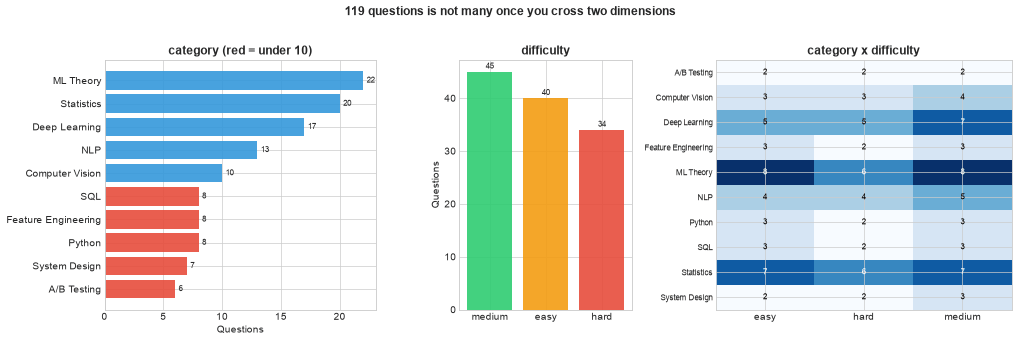

Categories with fewer than 10 questions: 5 of 10
Smallest category x difficulty cell: 2 questions
Median cell size: 3 questions

Difficulty is balanced (medium 45, easy 40, hard 34),
but the joint distribution is thin: most cells hold 2 to 8 questions, therefore
any per-cell statistic below is descriptive rather than inferential.


In [6]:
cat_counts = df["category"].value_counts()
diff_counts = df["difficulty"].value_counts()
crosstab = pd.crosstab(df["category"], df["difficulty"])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5.2),
                                    gridspec_kw={"width_ratios": [1.1, 0.7, 1.2]})

colors = ["#e74c3c" if n < 10 else "#3498db" for n in cat_counts.values]
bars = ax1.barh(cat_counts.index, cat_counts.values, color=colors, alpha=0.9)
ax1.invert_yaxis()
ax1.set_xlabel("Questions")
ax1.set_title("category (red = under 10)", fontweight="bold")
for bar, v in zip(bars, cat_counts.values):
    ax1.text(v + 0.3, bar.get_y() + bar.get_height() / 2, str(v), va="center", fontsize=9)

bars = ax2.bar(diff_counts.index, diff_counts.values,
               color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.9)
ax2.set_ylabel("Questions")
ax2.set_title("difficulty", fontweight="bold")
for bar, v in zip(bars, diff_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.6, str(v), ha="center", fontsize=9)

im = ax3.imshow(crosstab.values, cmap="Blues", aspect="auto")
ax3.set_xticks(range(crosstab.shape[1]))
ax3.set_xticklabels(crosstab.columns)
ax3.set_yticks(range(crosstab.shape[0]))
ax3.set_yticklabels(crosstab.index, fontsize=9)
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        ax3.text(j, i, crosstab.iloc[i, j], ha="center", va="center", fontsize=9,
                 color="white" if crosstab.iloc[i, j] > 5 else "black")
ax3.set_title("category x difficulty", fontweight="bold")

plt.suptitle("119 questions is not many once you cross two dimensions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Categories with fewer than 10 questions: "
      f"{int((cat_counts < 10).sum())} of {len(cat_counts)}")
print(f"Smallest category x difficulty cell: {crosstab.values.min()} questions")
print(f"Median cell size: {np.median(crosstab.values):.0f} questions")
print()
print("Difficulty is balanced (" + ", ".join(f"{k} {v}" for k, v in diff_counts.items()) + "),")
print("but the joint distribution is thin: most cells hold 2 to 8 questions, therefore")
print("any per-cell statistic below is descriptive rather than inferential.")

## 6. The Text Itself <a id='text'></a>

Answers are the substance of this corpus and questions are the index into it. The length
distributions below say how much text there is to work with, and the `answer_length`
comparison across difficulty levels says how little that length tells you.

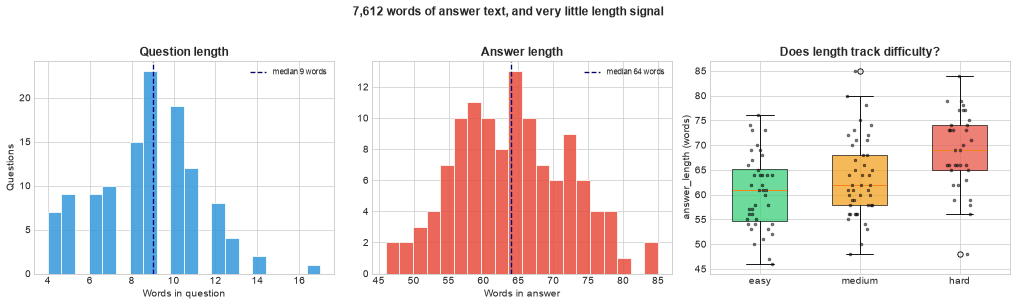

Question length: median 9 words, range 4-17
Answer length  : median 64 words, range 46-85 (7.1x the question)

answer_length by difficulty:
            size  min  median  max
difficulty                        
easy          40   46    61.0   76
hard          34   48    69.0   84
medium        45   48    62.0   85

Median spread across all three levels: 8 words,
against a within-level range of 46-85.
Therefore answer_length is not a usable proxy for difficulty.


In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.6))

ax1.hist(df["question_words"], bins=20, color="#3498db", alpha=0.85, edgecolor="white")
ax1.axvline(df["question_words"].median(), color="navy", linestyle="--",
            label=f"median {df['question_words'].median():.0f} words")
ax1.set_xlabel("Words in question")
ax1.set_ylabel("Questions")
ax1.set_title("Question length", fontweight="bold")
ax1.legend(fontsize=9)

ax2.hist(df["answer_words"], bins=20, color="#e74c3c", alpha=0.85, edgecolor="white")
ax2.axvline(df["answer_words"].median(), color="navy", linestyle="--",
            label=f"median {df['answer_words'].median():.0f} words")
ax2.set_xlabel("Words in answer")
ax2.set_title("Answer length", fontweight="bold")
ax2.legend(fontsize=9)

order = ["easy", "medium", "hard"]
data = [df.loc[df["difficulty"] == level, "answer_length"] for level in order]
bp = ax3.boxplot(data, tick_labels=order, patch_artist=True, widths=0.55)
for patch, color in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for i, level in enumerate(order, start=1):
    vals = df.loc[df["difficulty"] == level, "answer_length"]
    ax3.scatter(np.full(len(vals), i) + np.random.uniform(-0.13, 0.13, len(vals)),
                vals, s=9, alpha=0.5, color="black", zorder=3)
ax3.set_ylabel("answer_length (words)")
ax3.set_title("Does length track difficulty?", fontweight="bold")

plt.suptitle(f"{df['answer_words'].sum():,} words of answer text, and very little length signal",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Question length: median {df['question_words'].median():.0f} words, "
      f"range {df['question_words'].min()}-{df['question_words'].max()}")
print(f"Answer length  : median {df['answer_words'].median():.0f} words, "
      f"range {df['answer_words'].min()}-{df['answer_words'].max()} "
      f"({df['answer_words'].median() / df['question_words'].median():.1f}x the question)")
print()
print("answer_length by difficulty:")
print(df.groupby("difficulty")["answer_length"].agg(["size", "min", "median", "max"]).to_string())
print()
spread = df.groupby("difficulty")["answer_length"].median()
print(f"Median spread across all three levels: {spread.max() - spread.min():.0f} words,")
print(f"against a within-level range of {df['answer_length'].min()}-{df['answer_length'].max()}.")
print("Therefore answer_length is not a usable proxy for difficulty.")

## 7. `topic_tags` Is a Label, Not a Feature <a id='tags'></a>

`topic_tags` will be the strongest predictor of `category` in Section 8, and it should
not be used. The tags were written by hand alongside the category label, by the same
author, in the same pass — so they encode the answer rather than evidence for it. This is
annotation leakage: the same failure mode as training on a field that a human filled in
while looking at the target.

The measurement that makes it concrete: if the tags were a feature space, they would
recur across questions. Mostly they do not.

In [8]:
tags = df.assign(tag=df["topic_tags"].str.split("|")).explode("tag")
tag_counts = tags["tag"].value_counts()
tag_categories = tags.groupby("tag")["category"].nunique()

print("topic_tags as a feature space")
print("=" * 62)
print(f"Distinct tags                     : {tag_counts.size}")
print(f"Tags used exactly once in 119 rows: {int((tag_counts == 1).sum())} "
      f"({(tag_counts == 1).mean():.1%})")
print(f"Tags used in more than one category: {int((tag_categories > 1).sum())} "
      f"({(tag_categories > 1).mean():.1%})")
print(f"Tags per question                 : median {df['n_tags'].median():.0f}, "
      f"range {df['n_tags'].min()}-{df['n_tags'].max()}")
print()
print("Most reused tags:")
for tag, n in tag_counts.head(8).items():
    print(f"  {tag:<28} {n:>3} questions, {tag_categories[tag]} categories")
print()
print(f"With {(tag_counts == 1).mean():.0%} of tags appearing once, a model trained on them is")
print("memorising a per-question annotation. It cannot generalise to a new question,")
print("because a new question arrives with tags a human wrote after deciding its")
print("category — the very thing the model is supposed to predict.")

topic_tags as a feature space
Distinct tags                     : 181
Tags used exactly once in 119 rows: 118 (65.2%)
Tags used in more than one category: 28 (15.5%)
Tags per question                 : median 3, range 2-4

Most reused tags:
  optimization                  11 questions, 4 categories
  architecture                   9 questions, 3 categories
  language models                6 questions, 2 categories
  estimation                     6 questions, 1 categories
  neural networks                5 questions, 2 categories
  training                       5 questions, 3 categories
  feature engineering            5 questions, 3 categories
  inference                      5 questions, 2 categories

With 65% of tags appearing once, a model trained on them is
memorising a per-question annotation. It cannot generalise to a new question,
because a new question arrives with tags a human wrote after deciding its
category — the very thing the model is supposed to predict.


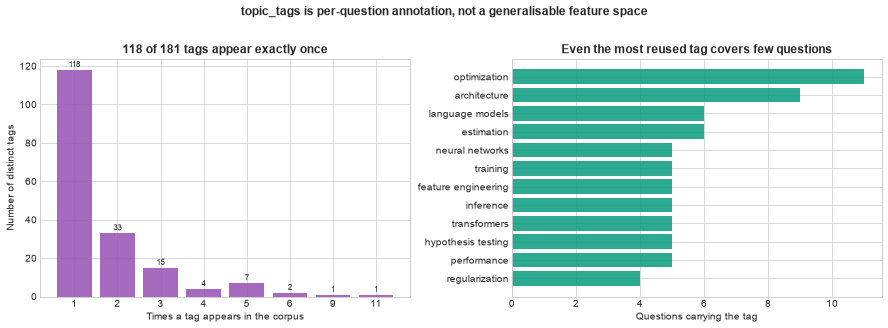

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

freq = tag_counts.value_counts().sort_index()
bars = ax1.bar(freq.index.astype(str), freq.values, color="#9b59b6", alpha=0.9)
for bar, v in zip(bars, freq.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 1.5, str(v), ha="center", fontsize=9)
ax1.set_xlabel("Times a tag appears in the corpus")
ax1.set_ylabel("Number of distinct tags")
ax1.set_title(f"{int((tag_counts == 1).sum())} of {tag_counts.size} tags appear exactly once",
              fontweight="bold")

top = tag_counts.head(12)[::-1]
ax2.barh(top.index, top.values, color="#16a085", alpha=0.9)
ax2.set_xlabel("Questions carrying the tag")
ax2.set_title("Even the most reused tag covers few questions", fontweight="bold")

plt.suptitle("topic_tags is per-question annotation, not a generalisable feature space",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Why There Is No Model Score <a id='nomodel'></a>

Here the classifiers are fitted — and every fold is printed rather than the mean, because
the mean is what makes an unusable evaluation look usable. Four inputs, one stratified
5-fold split, the same seed throughout.

Read the **spread** column, not the **mean** column.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y = df["category"]
tag_text = df["topic_tags"].str.replace("|", " ", regex=False)

INPUTS = {
    "majority class (baseline)": None,
    "question text": df["question"],
    "question + answer": df["question"] + " " + df["answer"],
    "topic_tags  [LEAK]": tag_text,
    "question + topic_tags  [LEAK]": df["question"] + " " + tag_text,
}

print(f"Stratified 5-fold, {len(df)} rows, {y.nunique()} classes, "
      f"~{len(df) // 5} rows per test fold")
print("=" * 88)
print(f"{'input':<32} {'mean':>7} {'spread':>9}   per-fold accuracy")
print("-" * 88)
scores = {}
for label, text in INPUTS.items():
    if text is None:
        s = cross_val_score(DummyClassifier(strategy="most_frequent"),
                            df[["answer_length"]], y, cv=cv, scoring="accuracy")
    else:
        pipe = make_pipeline(
            TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=1),
            LogisticRegression(max_iter=2000, C=10, random_state=SEED),
        )
        s = cross_val_score(pipe, text, y, cv=cv, scoring="accuracy")
    scores[label] = s
    folds = "  ".join(f"{v:.3f}" for v in s)
    print(f"{label:<32} {s.mean():>7.3f} {s.max() - s.min():>9.3f}   {folds}")
print("-" * 88)

worst = max(scores.items(), key=lambda kv: kv[1].max() - kv[1].min())
print(f"Widest spread: {worst[0]} ranges {worst[1].min():.3f} to {worst[1].max():.3f} "
      f"— {(worst[1].max() - worst[1].min()) * 100:.1f} points across folds of the SAME split.")
print(f"One test row is worth {1 / (len(df) / 5) * 100:.1f} accuracy points, so that spread")
print(f"is about {(worst[1].max() - worst[1].min()) * len(df) / 5:.0f} rows changing hands.")
print()
print("This is why no single accuracy figure appears in this notebook's summary. Two")
print("methods separated by 10 points here are indistinguishable, therefore any ranking")
print("of methods on this corpus reports the fold assignment, not the methods.")

Stratified 5-fold, 119 rows, 10 classes, ~23 rows per test fold
input                               mean    spread   per-fold accuracy
----------------------------------------------------------------------------------------
majority class (baseline)          0.185     0.042   0.208  0.208  0.167  0.167  0.174
question text                      0.345     0.167   0.333  0.375  0.250  0.417  0.348
question + answer                  0.537     0.167   0.458  0.583  0.542  0.625  0.478
topic_tags  [LEAK]                 0.681     0.333   0.708  0.542  0.542  0.875  0.739
question + topic_tags  [LEAK]      0.605     0.333   0.583  0.667  0.417  0.750  0.609
----------------------------------------------------------------------------------------
Widest spread: topic_tags  [LEAK] ranges 0.542 to 0.875 — 33.3 points across folds of the SAME split.
One test row is worth 4.2 accuracy points, so that spread
is about 8 rows changing hands.

This is why no single accuracy figure appears in this noteb

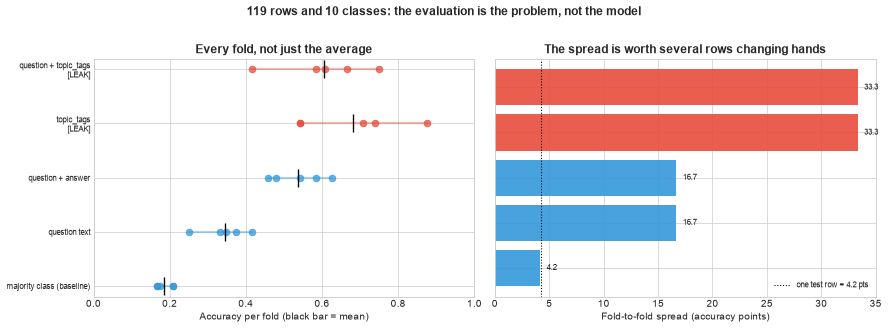

Vocabulary across all 119 questions: 444 distinct whitespace tokens.
A TF-IDF model on 95 training rows and a few hundred features is fitting more
parameters than it has examples, which is the other half of the instability.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = list(scores)
positions = np.arange(len(labels))
for i, label in enumerate(labels):
    s = scores[label]
    color = "#e74c3c" if "LEAK" in label else "#3498db"
    ax1.scatter(s, np.full(len(s), i), s=55, alpha=0.75, color=color, zorder=3)
    ax1.plot([s.min(), s.max()], [i, i], color=color, alpha=0.4, linewidth=2.5)
    ax1.scatter([s.mean()], [i], marker="|", s=380, color="black", zorder=4)
ax1.set_yticks(positions)
ax1.set_yticklabels([l.replace("  [LEAK]", "\n[LEAK]") for l in labels], fontsize=9)
ax1.set_xlabel("Accuracy per fold (black bar = mean)")
ax1.set_xlim(0, 1)
ax1.set_title("Every fold, not just the average", fontweight="bold")

spreads = [(scores[l].max() - scores[l].min()) * 100 for l in labels]
colors = ["#e74c3c" if "LEAK" in l else "#3498db" for l in labels]
bars = ax2.barh(positions, spreads, color=colors, alpha=0.9)
ax2.set_yticks(positions)
ax2.set_yticklabels(["" for _ in labels])
one_row = 1 / (len(df) / 5) * 100
ax2.axvline(one_row, color="black", linestyle=":", linewidth=1.2,
            label=f"one test row = {one_row:.1f} pts")
ax2.set_xlabel("Fold-to-fold spread (accuracy points)")
ax2.set_title("The spread is worth several rows changing hands", fontweight="bold")
ax2.legend(fontsize=9)
for bar, v in zip(bars, spreads):
    ax2.text(v + 0.6, bar.get_y() + bar.get_height() / 2, f"{v:.1f}", va="center", fontsize=9)

plt.suptitle("119 rows and 10 classes: the evaluation is the problem, not the model",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

vocab_size = len(set(" ".join(df["question"]).lower().split()))
print(f"Vocabulary across all 119 questions: {vocab_size} distinct whitespace tokens.")
print("A TF-IDF model on 95 training rows and a few hundred features is fitting more")
print("parameters than it has examples, which is the other half of the instability.")

### Why the question text struggles on its own

The 34.5% figure is not a failure of TF-IDF so much as a property of the vocabulary. ML
interview questions are written in shared language — "explain", "difference between",
"how does" — and the words that would identify a topic are rare precisely because each
topic has few questions. The measurement below separates those two effects.

In [12]:
import re
from collections import Counter

STOP = {"the", "a", "an", "is", "are", "what", "how", "why", "and", "or", "of", "to",
        "in", "for", "do", "does", "you", "your", "it", "its", "on", "between",
        "explain", "describe", "when", "which", "with", "this", "that", "would"}


def tokens(text):
    return {w for w in re.findall(r"[a-z]+", text.lower()) if w not in STOP and len(w) > 2}


question_tokens = df["question"].map(tokens)
vocab = Counter()
token_categories = {}
for toks, cat in zip(question_tokens, df["category"]):
    for tok in toks:
        vocab[tok] += 1
        token_categories.setdefault(tok, set()).add(cat)

exclusive = {t for t, cats in token_categories.items() if len(cats) == 1}
hapax = {t for t, n in vocab.items() if n == 1}
has_exclusive = question_tokens.map(lambda ts: bool(ts & exclusive))

print("Question vocabulary")
print("=" * 66)
print(f"Distinct content words (stopwords removed) : {len(vocab)}")
print(f"  appearing in exactly one question        : {len(hapax)} ({len(hapax) / len(vocab):.1%})")
print(f"  confined to a single category            : {len(exclusive)} ({len(exclusive) / len(vocab):.1%})")
print(f"  shared across two or more categories     : {len(vocab) - len(exclusive)} "
      f"({1 - len(exclusive) / len(vocab):.1%})")
print()
print(f"Questions containing at least one category-exclusive word: {has_exclusive.mean():.1%}")
print()
print("Most frequent content words, and how many categories they span:")
for tok, n in vocab.most_common(10):
    print(f"  {tok:<18} {n:>3} questions across {len(token_categories[tok])} categories")
print()
print(f"So the words that would give a category away are mostly hapax — {len(hapax) / len(vocab):.0%} of the")
print("vocabulary appears exactly once, which means the training folds have never seen")
print("them. The common words span several categories and therefore discriminate poorly.")
print("That is the trade-off a bag-of-words model faces here, and it is why the answer")
print("text helps: it repeats the question's rare terms in a longer context.")

Question vocabulary
Distinct content words (stopwords removed) : 375
  appearing in exactly one question        : 296 (78.9%)
  confined to a single category            : 314 (83.7%)
  shared across two or more categories     : 61 (16.3%)

Questions containing at least one category-exclusive word: 95.8%

Most frequent content words, and how many categories they span:
  difference          15 questions across 8 categories
  learning             8 questions across 5 categories
  feature              7 questions across 4 categories
  design               6 questions across 3 categories
  work                 6 questions across 5 categories
  important            6 questions across 4 categories
  models               5 questions across 3 categories
  from                 5 questions across 3 categories
  neural               5 questions across 3 categories
  system               5 questions across 2 categories

So the words that would give a category away are mostly hapax — 79% of the
voca

## 9. The Better-Posed Task: Retrieval <a id='retrieval'></a>

Section 8 ruled out classification on sample-size grounds. Retrieval does not have that
problem, and it is worth demonstrating rather than merely recommending.

The task: given a question, rank all 119 answers and check where the correct one lands.
Every row acts as a query, so the effective sample is **119** rather than the 24 a test
fold gave us — and the metric is a rank over a fixed candidate set, which does not
degrade as the class count grows. This is also the shape a RAG evaluation takes, which is
one of the uses this corpus is genuinely suited to.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fit the vectoriser on answers only, then project the questions into that space:
# an honest retrieval setup never fits on the queries it will be scored with.
vectoriser = TfidfVectorizer(sublinear_tf=True, stop_words="english", min_df=1)
answer_matrix = vectoriser.fit_transform(df["answer"])
question_matrix = vectoriser.transform(df["question"])

similarity = cosine_similarity(question_matrix, answer_matrix)
order = np.argsort(-similarity, axis=1)
gold = np.arange(len(df))
rank_of_gold = np.argmax(order == gold[:, None], axis=1) + 1

recall = {k: float((rank_of_gold <= k).mean()) for k in (1, 3, 5, 10)}
mrr = float((1 / rank_of_gold).mean())

print(f"TF-IDF retrieval over {len(df)} candidate answers")
print("=" * 62)
for k, value in recall.items():
    print(f"  Recall@{k:<3} {value:>7.1%}   (chance {k / len(df):>6.1%})")
print(f"  MRR       {mrr:>7.3f}   (chance {1 / len(df):.3f})")
print()
print(f"Median rank of the correct answer: {np.median(rank_of_gold):.0f} of {len(df)}")
print(f"Queries whose answer never reaches the top 10: "
      f"{int((rank_of_gold > 10).sum())} of {len(df)} ({(rank_of_gold > 10).mean():.1%})")
print()
print(f"Every one of the {len(df)} rows contributes a measurement here, against ~{len(df) // 5}")
print("per fold in section 8, therefore this metric is stable enough to compare two")
print("embedding models on — which the classification accuracy was not.")

TF-IDF retrieval over 119 candidate answers
  Recall@1     73.1%   (chance   0.8%)
  Recall@3     85.7%   (chance   2.5%)
  Recall@5     87.4%   (chance   4.2%)
  Recall@10    92.4%   (chance   8.4%)
  MRR         0.805   (chance 0.008)

Median rank of the correct answer: 1 of 119
Queries whose answer never reaches the top 10: 9 of 119 (7.6%)

Every one of the 119 rows contributes a measurement here, against ~23
per fold in section 8, therefore this metric is stable enough to compare two
embedding models on — which the classification accuracy was not.


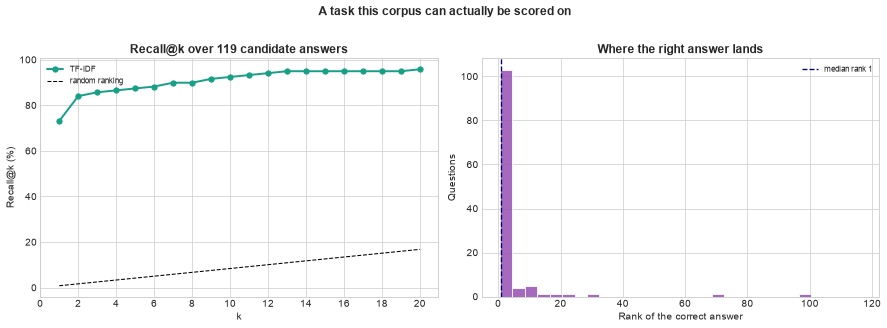

Hardest query — the question whose answer ranks lowest:
  Q: Design a recommendation system for an e-commerce platform.
  category: System Design  |  correct answer ranked 118 of 119
  Short questions sharing no rare vocabulary with their answer are where a
  lexical matcher fails, which is exactly the gap a dense retriever would close.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ks = list(range(1, 21))
curve = [(rank_of_gold <= k).mean() * 100 for k in ks]
ax1.plot(ks, curve, marker="o", linewidth=2.2, color="#16a085", label="TF-IDF")
ax1.plot(ks, [k / len(df) * 100 for k in ks], linestyle="--", color="black",
         linewidth=1.2, label="random ranking")
ax1.set_xlabel("k")
ax1.set_ylabel("Recall@k (%)")
ax1.set_xticks(range(0, 21, 2))
ax1.set_title(f"Recall@k over {len(df)} candidate answers", fontweight="bold")
ax1.legend(fontsize=9)

ax2.hist(rank_of_gold, bins=np.arange(0.5, len(df) + 1.5, 4), color="#9b59b6",
         alpha=0.9, edgecolor="white")
ax2.axvline(np.median(rank_of_gold), color="navy", linestyle="--",
            label=f"median rank {np.median(rank_of_gold):.0f}")
ax2.set_xlabel("Rank of the correct answer")
ax2.set_ylabel("Questions")
ax2.set_title("Where the right answer lands", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("A task this corpus can actually be scored on", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

worst_idx = int(np.argmax(rank_of_gold))
print("Hardest query — the question whose answer ranks lowest:")
print(f"  Q: {df['question'].iloc[worst_idx]}")
print(f"  category: {df['category'].iloc[worst_idx]}  |  "
      f"correct answer ranked {rank_of_gold[worst_idx]} of {len(df)}")
print("  Short questions sharing no rare vocabulary with their answer are where a")
print("  lexical matcher fails, which is exactly the gap a dense retriever would close.")

## 10. What This Corpus Is Actually For <a id='uses'></a>

Declining the classification task is not a verdict on the dataset. 119 carefully written
question-and-answer pairs across 10 ML topics are useful for several things that do not
require the corpus to be a statistical sample — and for those uses, hand-authored quality
matters far more than row count.

In [15]:
print("Fit for purpose")
print("=" * 74)
uses = [
    ("Study / revision material", True,
     f"{len(df)} Q&A pairs, {df['answer_words'].sum():,} words of answer text"),
    ("RAG or retrieval evaluation", True,
     f"{len(df)} labelled queries with known-correct passages"),
    ("Prompt / LLM spot-checking", True,
     f"{df['difficulty'].value_counts().min()}+ questions at each difficulty level"),
    ("Keyword and topic exploration", True,
     f"{tag_counts.size} tags over {df['category'].nunique()} categories"),
    ("Text-classification benchmark", False,
     f"{len(df)} rows / {df['category'].nunique()} classes = "
     f"{len(df) / 5 / df['category'].nunique():.1f} test rows per class per fold"),
    ("Difficulty prediction", False,
     f"answer_length medians differ by only "
     f"{spread.max() - spread.min():.0f} words across levels"),
    ("Fine-tuning a model", False,
     f"{df['answer_words'].sum():,} words is far below any useful fine-tuning corpus"),
]
for name, suitable, why in uses:
    mark = "YES" if suitable else "NO "
    print(f"  [{mark}] {name:<32} {why}")
print()
print("The pattern: uses that treat each row as CONTENT work; uses that treat each row")
print("as a SAMPLE do not, because 119 rows cannot estimate anything to a useful")
print("precision. That distinction is worth carrying to any small curated dataset.")

Fit for purpose
  [YES] Study / revision material        119 Q&A pairs, 7,612 words of answer text
  [YES] RAG or retrieval evaluation      119 labelled queries with known-correct passages
  [YES] Prompt / LLM spot-checking       34+ questions at each difficulty level
  [YES] Keyword and topic exploration    181 tags over 10 categories
  [NO ] Text-classification benchmark    119 rows / 10 classes = 2.4 test rows per class per fold
  [NO ] Difficulty prediction            answer_length medians differ by only 8 words across levels
  [NO ] Fine-tuning a model              7,612 words is far below any useful fine-tuning corpus

The pattern: uses that treat each row as CONTENT work; uses that treat each row
as a SAMPLE do not, because 119 rows cannot estimate anything to a useful
precision. That distinction is worth carrying to any small curated dataset.


## 11. Evaluation Readiness <a id='evaluation'></a>

In [16]:
print("Evaluation readiness checklist")
print("=" * 74)
print(f"Rows                  : {len(df)}")
print(f"Candidate target      : {TARGET_COL} ({df[TARGET_COL].nunique()} classes, "
      f"{counts.iloc[-1]}-{counts.iloc[0]} rows each)")
print(f"Metric                : {PRIMARY_METRIC}")
print(f"Majority-class floor  : {scores['majority class (baseline)'].mean():.3f}")
print()
print("Verdict: DO NOT report a single accuracy for this corpus.")
print(f"  Fold spread on the best input is {(worst[1].max() - worst[1].min()) * 100:.1f} points,")
print(f"  which exceeds the gap between every pair of inputs tested above except one.")
print()
print("If you model it anyway:")
print("  - Report every fold, plus repeated CV over several seeds. A single")
print("    StratifiedKFold(5) result on 119 rows is a coin flip with extra steps.")
print("  - DROP topic_tags. It was written alongside the category label by the same")
print(f"    author, and {(tag_counts == 1).mean():.0%} of its tags appear exactly once.")
print("  - Expect question text alone to sit near "
      f"{scores['question text'].mean():.2f}, against a "
      f"{scores['majority class (baseline)'].mean():.2f} floor.")
print("  - Merge the sub-10-row categories or accept that they are never predicted.")
print()
print("Better-posed alternatives on the same file:")
print("  - Retrieval: given a question, rank all 119 answers. Recall@k on 119 candidates")
print("    is a meaningful metric at this size, because every row is used as a query.")
print("  - Binary difficulty (easy vs hard) drops the class count from 10 to 2 and")
print(f"    gives {int((df['difficulty'] != 'medium').sum())} usable rows, which is still small but evaluable.")

Evaluation readiness checklist
Rows                  : 119
Candidate target      : category (10 classes, 6-22 rows each)
Metric                : per-fold accuracy spread, not a mean
Majority-class floor  : 0.185

Verdict: DO NOT report a single accuracy for this corpus.
  Fold spread on the best input is 33.3 points,
  which exceeds the gap between every pair of inputs tested above except one.

If you model it anyway:
  - Report every fold, plus repeated CV over several seeds. A single
    StratifiedKFold(5) result on 119 rows is a coin flip with extra steps.
  - DROP topic_tags. It was written alongside the category label by the same
    author, and 65% of its tags appear exactly once.
  - Expect question text alone to sit near 0.34, against a 0.18 floor.
  - Merge the sub-10-row categories or accept that they are never predicted.

Better-posed alternatives on the same file:
  - Retrieval: given a question, rank all 119 answers. Recall@k on 119 candidates
    is a meaningful metric at

## 12. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above. Nothing is asserted that the notebook does
not also compute.

### Finding 1 — the corpus is too small to evaluate a classifier, and that is measurable

Each stratified test fold holds **23-24 rows** across **10** categories. One row is worth
**4.2 accuracy points**. The best-scoring input swings from **54.2%** to **87.5%** across
five folds of a single split — a **33.3-point** spread, or roughly 8 rows changing hands.
Two methods separated by 10 points on this corpus are indistinguishable, **therefore**
publishing a mean accuracy here reports the fold assignment rather than the method. This
notebook prints all five folds and declines to name a headline number.

### Finding 2 — `topic_tags` is annotation leakage and it is the strongest "feature"

Tags score highest of everything tested, which is exactly the warning sign. They were
hand-written by the same author who assigned `category`, in the same pass, so they encode
the label rather than evidence for it. **118 of 181** distinct tags appear exactly once
across all 119 questions — they are per-question annotations, not a feature space. A
model trained on them cannot generalise, **because** a genuinely new question arrives
without tags, or with tags a human wrote after already deciding the category.

### Finding 3 — question text carries a real but small signal

TF-IDF on question text alone averages **34.5%** against a majority-class floor of
**18.5%** — roughly double the floor, on a vocabulary of just **444** distinct tokens
across all 119 questions. Adding the answer text lifts the average to **53.7%**, but the
trade-off is that answers are **7.1×** longer than questions, so most of that gain is
simply more text rather than better-suited text. Both figures carry the same fold-spread
caveat as everything else in Section 8. The vocabulary measurement explains the ceiling:
after stopword removal the questions hold few content words, most of them appearing
exactly once, so the terms that identify a topic are precisely the ones a training fold
has never seen.

### Finding 4 — `answer_length` does not encode difficulty

Median answer length is **61** words for easy questions, **62** for medium and **69** for
hard, inside an overall range of **46-85**. The three distributions overlap almost
completely. The observation matters because `answer_length` is the only numeric column in
the file, which makes it the column a template EDA reaches for — and it is a dead end.

### Finding 5 — coverage is balanced on difficulty and lopsided on topic

`difficulty` splits **40 / 45 / 34** across easy, medium and hard. `category` runs from
**22** questions (ML Theory) down to **6** (A/B Testing), with **5 of 10** categories
under 10 questions. Crossing the two leaves a median cell of **3** questions. This is a
sensible shape for study material, which should weight common interview topics, and an
unusable shape for stratified evaluation.

### Finding 6 — retrieval works on this corpus, and it is the task to use

Ranking all 119 answers for each question with plain TF-IDF puts the correct answer
first for **73.1%** of queries and in the top five for **87.4%**, against chance rates of
**0.8%** and **4.2%**. Median rank of the correct answer is **1**, and only **9 of 119**
queries fail to reach the top ten. This works where classification did not **because**
every row contributes a measurement rather than one in five, and because matching a
question to its own answer only requires shared rare vocabulary rather than a decision
boundary between ten thinly-populated classes.

### Limitations and caveats

- **This is a hand-authored corpus**, not a sample of anything. It reflects one author's
  view of what gets asked in ML interviews, so the topic weighting is an editorial
  judgement rather than a measurement of interview practice.
- **Every quantitative result in Section 8 inherits the instability it is measuring.** The
  34.5% and 53.7% figures are themselves five-fold means on 24-row folds; they are cited
  as evidence that a signal exists, not as estimates of its size.
- **119 rows cannot support subgroup analysis.** Nothing in this notebook is broken down
  by category and difficulty jointly, because the median cell holds 3 questions.
- **The answers are not verified.** They read as competent, but this notebook checks
  structure and coverage, not correctness, and no external source was consulted.
- **A negative result about evaluability is not a negative result about content.**
  Section 9 lists four uses this corpus serves well.

### Conclusion and next steps

The habit worth taking from this one: work out what your evaluation can resolve before
choosing a metric to report. A 33-point fold spread means the experiment cannot
distinguish the things it was set up to distinguish, and no amount of model tuning
changes that — the fix has to be more data or a different question.

Recommended next steps:

- **Improve on the TF-IDF retrieval baseline in Section 9.** A sentence-embedding model
  should beat Recall@1 = 73.1% comfortably, and unlike the classification accuracy that
  comparison is actually measurable on 119 rows.
- **Use repeated stratified CV if you classify anyway.** Twenty repeats of 5-fold with
  different seeds turns the 33-point single-split spread into a distribution you can put a
  confidence interval on — which will show that most method differences are inside it.
- **Grow the corpus before benchmarking it.** Roughly 30 questions per category, or ~300
  rows, would bring per-class test counts to 6 and make a stratified comparison
  meaningful.
- **Build the difficulty task properly.** `answer_length` fails, but answer *content* —
  formula density, jargon rate, number of distinct concepts named — is untested and is the
  obvious place to look next.

*This is a small hand-curated teaching corpus. It is built for study, retrieval
evaluation and prompt testing, not for benchmarking text classifiers.*